In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("../data/train.csv")

In [17]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [20]:
df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

# 3. Data Cleaning

In [22]:
# fix datatype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [23]:
# Drop irrelevant feature
df = df.drop("customerID", axis=1)

In [24]:
#target encoding
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# 4. EDA

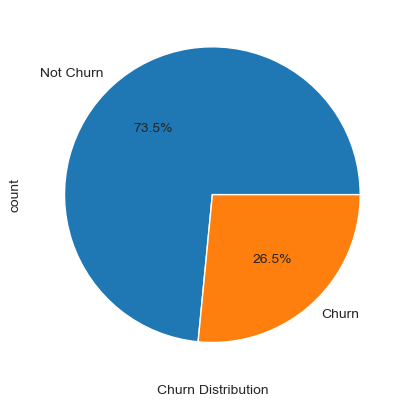

In [25]:
df["Churn"].value_counts().plot.pie(
    autopct = "%1.1f%%",
    labels = ["Not Churn", "Churn"]
)
plt.xlabel("Churn Distribution")
plt.show()

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

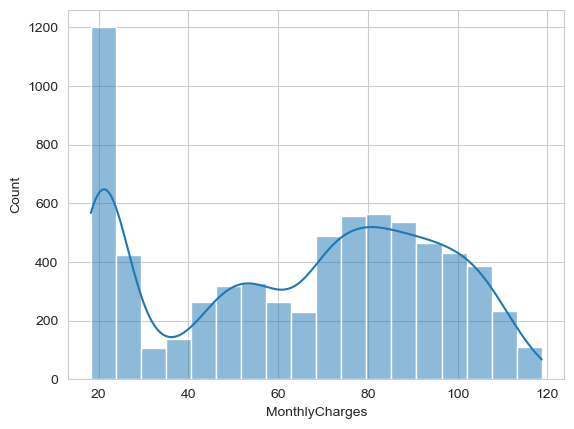

In [26]:
sns.histplot(df["MonthlyCharges"], kde = True)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

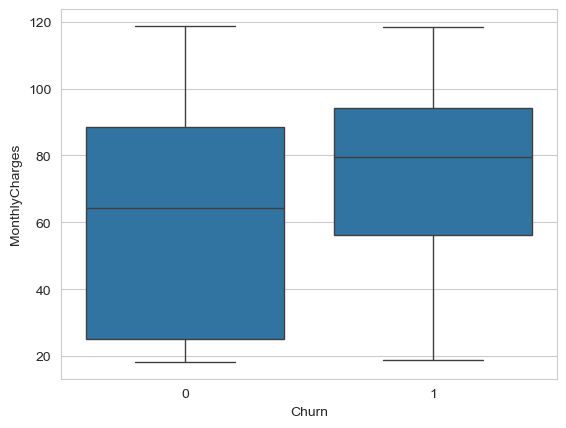

In [27]:
sns.boxplot(x = "Churn", y = "MonthlyCharges", data = df)

<Axes: xlabel='Contract', ylabel='count'>

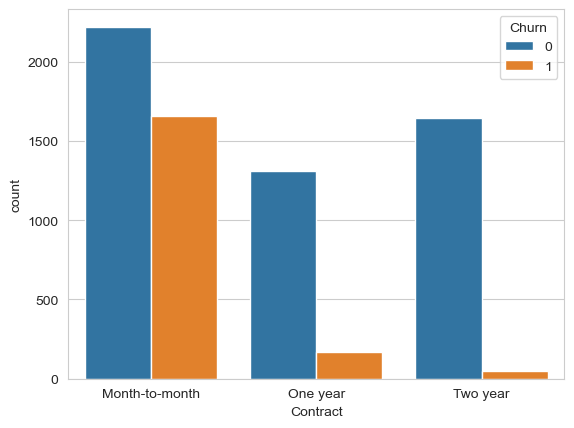

In [28]:
sns.countplot(data = df, x = "Contract", hue = "Churn")

<Axes: >

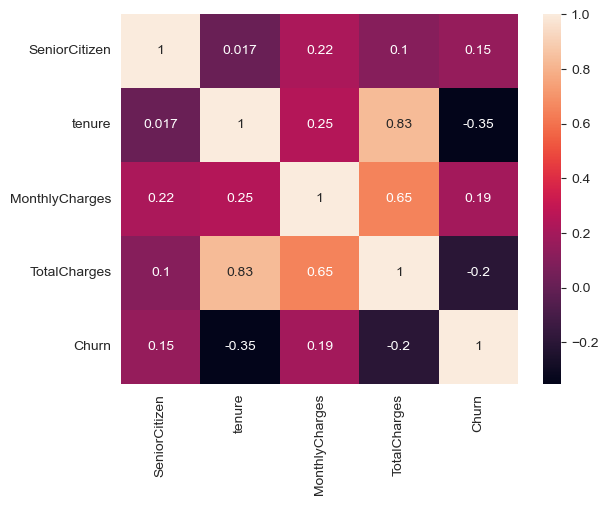

In [29]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

# 5 Feature Engineering

In [30]:
df["AvgCharges"] = df["TotalCharges"] / (df["tenure"] + 1)
# from sklearn.preprocessing import FunctionTransformer
# def add_features(X):
#     X = X.copy()
#     
#     # avoid division by zero
#     X["AvgCharges"] = X["TotalCharges"] / (X["tenure"] + 1)
#     
#     return X

# 6 Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X = df.drop(columns = "Churn", axis = 1)
y = df["Churn"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# 7. Preprocessing

In [34]:
num_cols = X.select_dtypes(include = np.number).columns.tolist()
cat_cols = X.select_dtypes(include = "object").columns.tolist()

In [36]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [84]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [85]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [86]:
ord_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder())
])

In [87]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)

In [88]:
from imblearn.pipeline import Pipeline as Pipeline
from imblearn.over_sampling import SMOTE

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 8 Modeling

In [90]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVC": SVC(probability=True),
    "XGB": XGBClassifier(eval_metric='logloss')
}

# 9 Cross Validation

In [91]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [92]:
results = {}

cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

for name, model in models.items():
    
    if name in ["LogisticRegression", "RandomForest", "DecisionTree"]:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])
    else:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])
    
    
    scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv = cv,
        scoring= scoring,
        n_jobs=-1
    )
    
    results[name] = {
        metric: {
            "mean": scores[f'test_{metric}'].mean(),
            "std": scores[f'test_{metric}'].std()
        }
        for metric in scoring
    }

In [93]:
df_results = pd.DataFrame({
    model: {metric: vals["mean"] for metric, vals in metrics.items()}
    for model, metrics in results.items()
}).T

df_results.sort_values("recall", ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.760210,0.533076,0.781940,0.633848,0.847698
KNN,0.766952,0.566947,0.523746,0.544036,0.781912
DecisionTreeClassifier,0.730214,0.492726,0.509699,0.500865,0.659971
XGB,0.783637,0.612472,0.503010,0.552044,0.820321
RandomForestClassifier,0.790382,0.638945,0.483612,0.550323,0.822873
SVC,0.801386,0.677083,0.482943,0.563360,0.799382


In [94]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [95]:
param_grid = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    "RandomForestClassifier": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__class_weight": [None, "balanced"]
    },
    "DecisionTreeClassifier": {
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__class_weight": [None, "balanced"]
    },
    "KNN" : {
        "model__n_neighbors": [3, 5, 7, 11],
        "model__weights": ["uniform", "distance"]
    },
    "SVC" : {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
        "model__class_weight": [None, "balanced"]
    },
    "XGB" : {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6, 10],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__scale_pos_weight": [1, ratio, ratio*2]
    }
}

# Hyperparameter Tuning

In [96]:
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

tuning_results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe, 
        param_grid[name],
        cv=cv,
        scoring="recall",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    # test evaluation
    y_pred = best_model.predict(X_test)
    
    
    test_recall = recall_score(y_test, y_pred)
    test_auc = roc_auc_score(
        y_test,
        best_model.predict_proba(X_test)[:,1]
    )
    
    
    tuning_results[name] = {
        "best_cv_score": grid.best_score_,
        "cv_std": grid.cv_results_["std_test_score"][grid.best_index_],
        "test_recall": test_recall,
        "test_auc": test_auc,
        "best_params": grid.best_params_
    }
    tuning_results[name]["model"] = best_model

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [97]:
df_results = pd.DataFrame(tuning_results).T
df_results.sort_values("test_recall", ascending=False)

,best_cv_score,cv_std,test_recall,test_auc,best_params,model
XGB,0.945819,0.012762,0.946524,0.837079,"{'model__learning_rate': 0.01, 'model__max_dep...",(FunctionTransformer(func=<function add_featur...
SVC,0.818729,0.031757,0.802139,0.843323,"{'model__C': 10, 'model__class_weight': 'balan...",(FunctionTransformer(func=<function add_featur...
RandomForestClassifier,0.797993,0.022841,0.794118,0.83849,"{'model__class_weight': 'balanced', 'model__ma...",(FunctionTransformer(func=<function add_featur...
LogisticRegression,0.799331,0.030943,0.780749,0.846534,"{'model__C': 0.1, 'model__class_weight': 'bala...",(FunctionTransformer(func=<function add_featur...
DecisionTreeClassifier,0.772575,0.025206,0.759358,0.831165,"{'model__class_weight': 'balanced', 'model__ma...",(FunctionTransformer(func=<function add_featur...
KNN,0.545151,0.006689,0.569519,0.812451,"{'model__n_neighbors': 11, 'model__weights': '...",(FunctionTransformer(func=<function add_featur...


In [98]:
df_results = df_results.sort_values("best_cv_score", ascending=False)

In [99]:
best_model_name = df_results.index[0]
print("Best Model:", best_model_name)

Best Model: XGB


In [100]:
best_model = tuning_results[best_model_name]["model"]
best_model

,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function add...001FD98BB1120>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [101]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [102]:
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.96      0.49      0.65      1035
           1       0.40      0.95      0.56       374

    accuracy                           0.61      1409
   macro avg       0.68      0.72      0.60      1409
weighted avg       0.81      0.61      0.62      1409

ROC-AUC: 0.8370792322198972


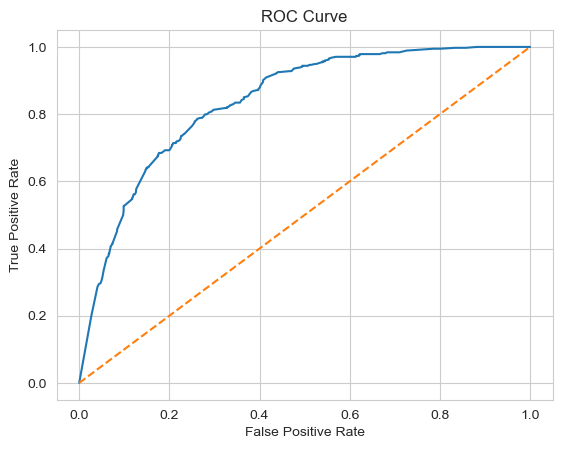

In [103]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [104]:
y_pred_custom = (y_proba >= 0.3).astype(int)

In [105]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred_custom)

0.9973262032085561

In [106]:
import joblib

joblib.dump(best_model, "../model/churn_model.pkl")

['churn_model.pkl']